# Instructions
Prepare a small synthetic example to illustrate this:
- Generate data for ~500 genes and ~30 pathways (pathways static across all samples), with gene expression varying per sample
- Create ~1000 samples, with labels split roughly 50/50 between Disease A and Healthy
- Ensure some genes are differentially expressed between Disease A and Healthy, while some remain identical across both groups

Build a graph suitable for a GNN (PyTorch Geometric is perfect) and train a simple model (e.g., GAT) for classification

Run GNNExplainer on the trained model to highlight what drives the prediction and demonstrate the differences in explanations between Disease A and Healthy (and add a brief note on how you would sanity-check explanation stability)

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.explain import Explainer, GNNExplainer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os
import networkx as nx


In [32]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False) 

set_seed(42)

## Data generation
Let´s create a gene-gene interaction network, where nodes represent genes and edges represent shared pathways. The features for each gene node will be its expression level across all 1,000 samples.

In [33]:
# Parameters
n_genes = 500
n_pathways = 30
n_samples = 1000

In [34]:
# Create gene-pathway map (edges)
# Each gene belongs only to one primary pathway for this example
gene2pathway_idx = np.random.randint(0, n_pathways, size=n_genes)
edge_idx = []
for i in range(n_genes):
    for j in range(i + 1, n_genes):
        if gene2pathway_idx[i] == gene2pathway_idx[j]:
            edge_idx.append([i, j])
            edge_idx.append([j, i])
edge_idx = torch.tensor(edge_idx, dtype=torch.long).t()

In [35]:
# Create sample labels (50/50 disease vs healthy)
labels = np.array([1] * 500 + [0] * 500) # 1: Disease A, 0: Healthy
np.random.shuffle(labels)

In [36]:
# Generate gene expression
expression = np.random.normal(0, 1, (n_genes, n_samples)) # Initialize with random noise
# Inject differential expression (DE) for some genes: genes 0-50 highly upregulated in Disease A (label 1)
disease_idx = np.where(labels == 1)[0]
expression[0:50, disease_idx] += 2.5
# Remaining genes 51-500 remain identical (noise only) across both groups
x = torch.tensor(expression, dtype=torch.float) 
y = torch.tensor(labels, dtype=torch.float)

In [37]:
# Create PyG graph 
data_list = []
for i in range(n_samples):
    sample_x = torch.tensor(expression[:, i], dtype=torch.float).view(-1, 1) # PyG expects (num_nodes=500, num_features=1)
    sample_y = torch.tensor([labels[i]], dtype=torch.float)
    # All samples share the same edge_index (the network structure)
    d = Data(x=sample_x, edge_index=edge_idx, y=sample_y)
    data_list.append(d)


In [38]:
# Train-validation split
train_split = 0.8
n_train = int(train_split * n_samples)
train_loader = DataLoader(data_list[:n_train], batch_size=32, shuffle=True)
val_loader = DataLoader(data_list[n_train:], batch_size=32, shuffle=False)

## Modelling 
The problem is formulated as a graph classification problem, where one label is predicted per graph. Graph Attention Network (GAT) to predict samples' labels based on the gene interaction graph exploiting the aggregated node features and the attention mechanism (i.e., scoring the relevance of each node´s neighbors) typical of GATs, followed by a pooling layer that "squashes" the gene embeddings into a single vector that becomes the sample's representation of its gene expression. 

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [40]:
class GATClassifier(torch.nn.Module):
    def __init__(self):
            super().__init__()
            self.conv1 = GATConv(1, 16, heads=4) # in_channels=1 (expression value)
            self.conv2 = GATConv(64, 16, heads=1)
            self.classifier = torch.nn.Linear(16, 1)

    def forward(self, x, edge_index, batch=None):
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)        
        # pooling into a graph-level embedding
        x = global_mean_pool(x, batch)
        x = self.classifier(x)
        return torch.sigmoid(x)

In [44]:
model = GATClassifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCELoss()

In [45]:
# Training loop
train_losses = []
val_losses = []

for epoch in range(101):
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y.view(-1, 1))
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * batch.num_graphs
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    # validation
    model.eval()
    total_val_loss = 0
    correct = 0
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            v_loss = criterion(out, batch.y.view(-1, 1))
            total_val_loss += v_loss.item() * batch.num_graphs
            # accuracy
            pred = (out > 0.5).float() # predictions to 0 / 1
            correct += (pred == batch.y.view(-1, 1)).sum().item()
    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    val_acc = correct / len(val_loader.dataset)
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | Val Acc: {val_acc:.4f}")

Epoch   0 | Train Loss: 0.658254 | Val Loss: 0.627226 | Val Acc: 0.5050
Epoch  20 | Train Loss: 0.003031 | Val Loss: 0.003187 | Val Acc: 1.0000
Epoch  40 | Train Loss: 0.000780 | Val Loss: 0.000957 | Val Acc: 1.0000
Epoch  60 | Train Loss: 0.000344 | Val Loss: 0.000453 | Val Acc: 1.0000
Epoch  80 | Train Loss: 0.000187 | Val Loss: 0.000275 | Val Acc: 1.0000
Epoch 100 | Train Loss: 0.000114 | Val Loss: 0.000174 | Val Acc: 1.0000


In [47]:
from sklearn.metrics import classification_report, roc_auc_score

model.eval()
y_true = []
y_pred_probs = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred_probs.extend(out.cpu().numpy())

y_pred_labels = (np.array(y_pred_probs) > 0.5).astype(int)
auc = roc_auc_score(y_true, y_pred_probs)

print("\n--- Final Validation Metrics ---")
print(f"ROC-AUC Score: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred_labels, target_names=['Healthy', 'Disease A']))


--- Final Validation Metrics ---
ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       108
   Disease A       1.00      1.00      1.00        92

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



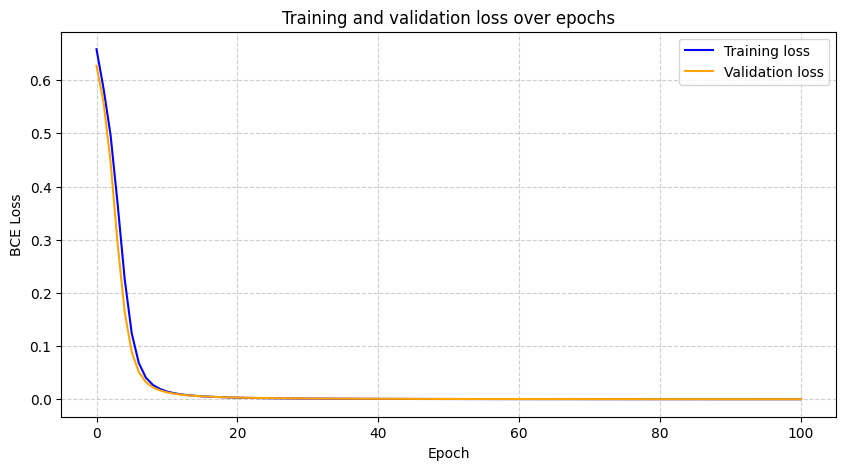

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training loss', color='blue')
plt.plot(val_losses, label='Validation loss', color='orange')
plt.title('Training and validation loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Interpretation with GNN explainer
GNNExplainer is used to identify the minimal subnetwork (pathway) that explains the prediction.

In [49]:
explainer = Explainer(
    model=model,  # This now points to the updated instance
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='binary_classification',
        task_level='graph',
        return_type='probs',
    ),
)

In [50]:
def get_global_mask(samples, explainer):
    device = next(explainer.model.parameters()).device
    global_mask = torch.zeros(edge_idx.shape[1], device=device)
    for s in samples:
        s = s.to(device)
        exp = explainer(s.x, s.edge_index) 
        global_mask += exp.edge_mask
    return (global_mask / len(samples)).cpu()

In [51]:
# Separate val samples into healthy and disease
disease_val = [d for d in data_list[800:] if d.y == 1]
healthy_val = [d for d in data_list[800:] if d.y == 0]

# Compute signatures
disease_sig = get_global_mask(disease_val, explainer)
healthy_sig = get_global_mask(healthy_val, explainer)

In [52]:
# Calculate differential importance (highlight edges that are important for classifying disease)
diff_importance = torch.clamp(disease_sig - healthy_sig, min=0)

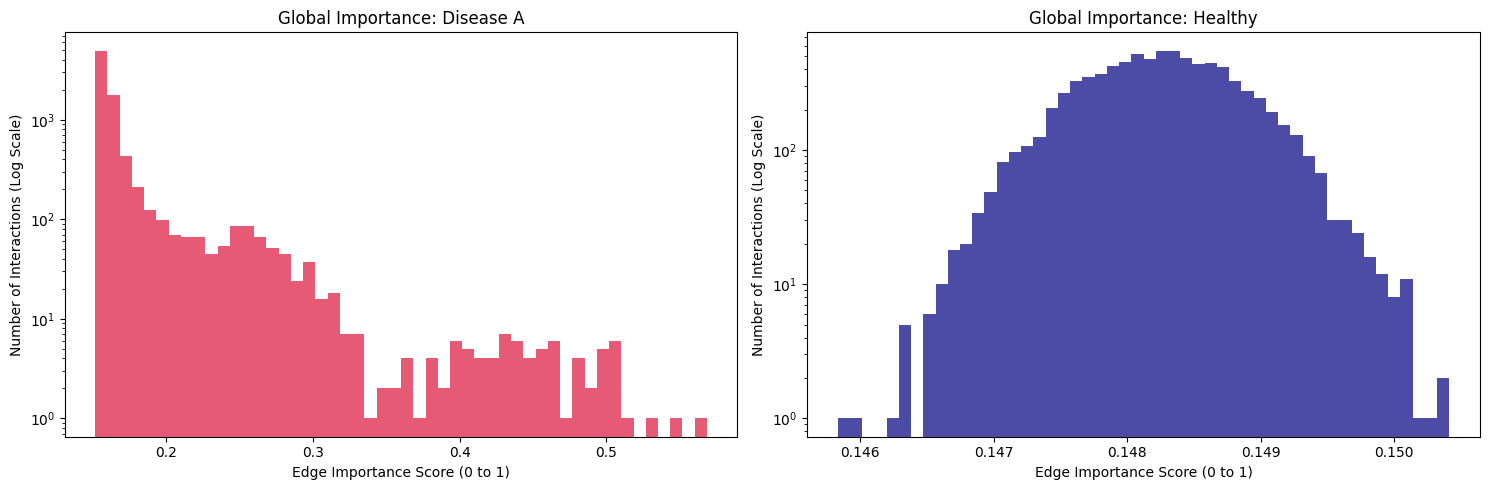

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Plot disease signature
axes[0].hist(disease_sig.numpy(), bins=50, color='crimson', alpha=0.7)
axes[0].set_title("Global Importance: Disease A")
axes[0].set_yscale('log')
axes[0].set_xlabel("Edge Importance Score (0 to 1)")
axes[0].set_ylabel("Number of Interactions (Log Scale)")

# plot healthy signature
axes[1].hist(healthy_sig.numpy(), bins=50, color='navy', alpha=0.7)
axes[1].set_title("Global Importance: Healthy")
axes[1].set_yscale('log')
axes[1].set_xlabel("Edge Importance Score (0 to 1)")
axes[1].set_ylabel("Number of Interactions (Log Scale)")

plt.tight_layout()
plt.show()

In the disease A plot, the bars at higher importance scores (0.45-0.7) represent that the GNN has identified certain interactions as relevant drivers for the "Disease A" label, while most edges are clustered below 0.2, meaning the model correctly ignores the bulk of the "noise" genes in the network.

The edge importance score across the healthy samples displays a standard normal distribution concentrated in a very narrow, low range (0.145 to 0.150). For these samples, no interactions stand out as drivers.

In [54]:
# Extracting the differential "driver" edges
top_diff = diff_importance.argsort(descending=True)[:20]
print("Top 20 gene-gene interactions relevant for disease A:")
for idx in top_diff:
    u, v = edge_idx[:, idx]
    print(f"Interaction: gene {u.item()} - gene {v.item()} | Importance: {diff_importance[idx]:.4f}")

Top 20 gene-gene interactions relevant for disease A:
Interaction: gene 10 - gene 49 | Importance: 0.4199
Interaction: gene 49 - gene 10 | Importance: 0.3979
Interaction: gene 33 - gene 20 | Importance: 0.3794
Interaction: gene 20 - gene 33 | Importance: 0.3668
Interaction: gene 9 - gene 32 | Importance: 0.3614
Interaction: gene 13 - gene 4 | Importance: 0.3584
Interaction: gene 2 - gene 6 | Importance: 0.3566
Interaction: gene 47 - gene 44 | Importance: 0.3548
Interaction: gene 4 - gene 13 | Importance: 0.3541
Interaction: gene 44 - gene 47 | Importance: 0.3539
Interaction: gene 32 - gene 9 | Importance: 0.3521
Interaction: gene 38 - gene 39 | Importance: 0.3516
Interaction: gene 3 - gene 47 | Importance: 0.3510
Interaction: gene 39 - gene 38 | Importance: 0.3502
Interaction: gene 47 - gene 3 | Importance: 0.3461
Interaction: gene 22 - gene 27 | Importance: 0.3439
Interaction: gene 34 - gene 6 | Importance: 0.3377
Interaction: gene 13 - gene 12 | Importance: 0.3362
Interaction: gene 8

NOTE: Although the graph is undirected, PyTorch geometric represents undirected graphs as 'pairs of directed edges', so even though the biological interaction in this case is the same, GNNExplainer treats these as two distinct computational paths. To ease the biological interpretation in a real world usecase, this could be addressed by averaging the scores to get a consolidated unique score per node pair. Slight differences between the pairs of directed edges are due to different neighborhood context and the stochastic optimization of GNNExplainer which involves a bit of noise. Also, note that typical real-world molecular interaction graphs are heterogeneous, hence directed edges may have a biological interpretation in those cases.

Here some example code on how to identify unique gene-gene interaction pairs:

In [67]:
# Consolidate scores by averaging bidirectional edges (average the scores for each unique gene-gene interaction)
undirected_scores = {}
for idx in range(edge_idx.shape[1]):
    u, v = edge_idx[:, idx].tolist()
    pair = tuple(sorted((u, v)))
    if pair not in undirected_scores:
        undirected_scores[pair] = []
    undirected_scores[pair].append(diff_importance[idx].item())
unique_top_edges = []
for (u, v), scores in undirected_scores.items():
    avg_score = sum(scores) / len(scores)
    unique_top_edges.append((u, v, avg_score))

# sort
unique_top_edges.sort(key=lambda x: x[2], reverse=True)
print("Top 10 gene-gene interactions (averaged importance score):")
for i in range(min(10, len(unique_top_edges))):
    u, v, score = unique_top_edges[i]
    print(f"Interaction: gene {u} - gene {v} | Avg edge importance: {score:.4f}")

Top 10 gene-gene interactions (averaged importance score):
Interaction: gene 10 - gene 49 | Avg edge importance: 0.4089
Interaction: gene 20 - gene 33 | Avg edge importance: 0.3731
Interaction: gene 9 - gene 32 | Avg edge importance: 0.3568
Interaction: gene 4 - gene 13 | Avg edge importance: 0.3562
Interaction: gene 44 - gene 47 | Avg edge importance: 0.3543
Interaction: gene 38 - gene 39 | Avg edge importance: 0.3509
Interaction: gene 3 - gene 47 | Avg edge importance: 0.3485
Interaction: gene 22 - gene 27 | Avg edge importance: 0.3365
Interaction: gene 2 - gene 6 | Avg edge importance: 0.3359
Interaction: gene 12 - gene 13 | Avg edge importance: 0.3329


The genes appearing in the top 10 gene-gene interactions list (10, 49, 20, 33, 9, 32, 4, 13, 44,...) are all within the 0–50 range that were manually upregulated for Disease A.
This proves that:
- The GNN captured the signal: The model didn't just learn "noise"; it specifically looked at the neighborhood of genes with differential expression.
- The Explainer is accurate: The `GNNExplainer` successfully isolated the specific interactions within those pathways that drove the "Disease A vs healthy" classification.
- Contrastive logic: The `diff_importance` calculation effectively filtered out the other 450 genes (51–500) that were not different in the groups.

Let´s visualize the relevant subnetworks:

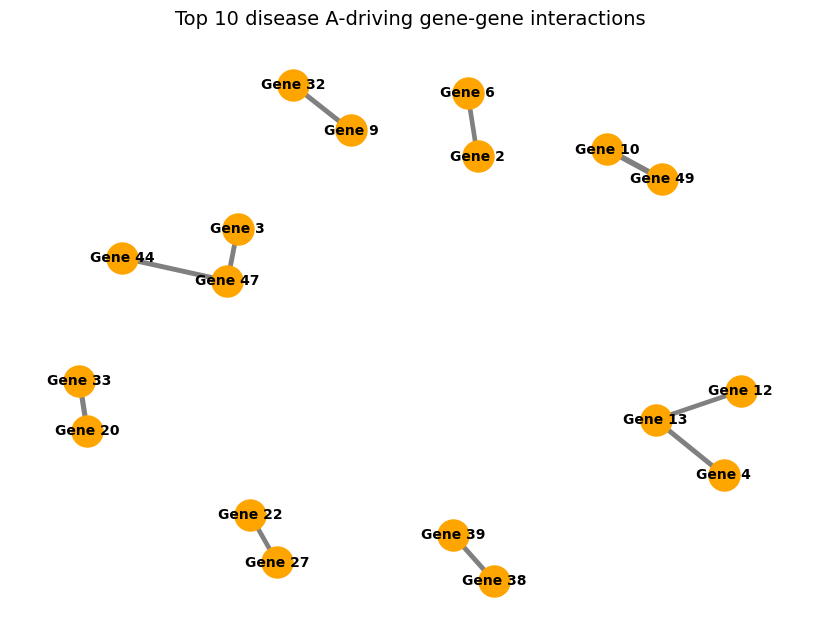

In [71]:
G = nx.Graph()
for u, v, score in unique_top_edges[:10]:
    G.add_edge(f"Gene {u}", f"Gene {v}", weight=score)

# Plot
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, k=0.4, seed=42) # Seed for consistent layout

# Scale weights for better visual representation
weights = [G[u][v]['weight'] * 10 for u, v in G.edges()]
nx.draw(G, pos, with_labels=True, 
        node_color='orange', node_size=500, 
        font_size=10, font_weight='bold',
        width=weights, edge_color='gray')

plt.title("Top 10 disease A-driving gene-gene interactions", fontsize=14)
plt.show()

### Stability sanity check
To ensure these subnetworks are robust and not artifacts of a specific model initialization, I would implement the following stability checks:
- Cross-validation consistency: The pipeline should be run across 5- or 10-fold cross-validation and calculate the Jaccard similarity of the top 50 edges across folds. High overlap indicates a stable technical and biological signal.
- Seed robustness: The model should be trained with different random seeds. If the same genes (0-50) consistently emerge as drivers, the explanation is computationally stable.
- Perturbation analysis: Randomly remove a percentage of the "non-driver" edges (e.g., 5%). A stable explainer should still identify the same core subnetwork as the primary driver.